In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import xgboost as xgb

In [14]:
df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')
df_features= pd.read_csv('/content/features.csv')
df_stores = pd.read_csv('/content/stores.csv')

In [15]:
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [16]:
df_test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [17]:
df_features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [18]:
df_stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [19]:
print(df_train.dtypes)

Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object


In [20]:
print(df_test.dtypes)

Store         int64
Dept          int64
Date         object
IsHoliday      bool
dtype: object


In [21]:
print(df_features.dtypes)

Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object


In [22]:
print(df_stores.dtypes)

Store     int64
Type     object
Size      int64
dtype: object


We have Date in Object in all our dataframe which is not correct datatype so we need to change it to datetime and also the store type is in Object that too we need to change it by converting the datatype to Category

In [23]:
df_train['Date'] = pd.to_datetime(df_train['Date'])
df_test['Date'] = pd.to_datetime(df_test['Date'])
df_features['Date'] = pd.to_datetime(df_features['Date'])

In [24]:
df_stores['Type'] = df_stores['Type'].astype('category')

In [25]:
print(df_stores.dtypes)

Store       int64
Type     category
Size        int64
dtype: object


In [29]:
print(df_features.dtypes)
print("--------------------------------")
print(df_test.dtypes)
print("---------------------------------")
print(df_train.dtypes)

Store                    int64
Date            datetime64[ns]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
dtype: object
--------------------------------
Store                 int64
Dept                  int64
Date         datetime64[ns]
IsHoliday              bool
dtype: object
---------------------------------
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object


Successfully we have changed the datatype of Date and Type to Datetime and Category

In [30]:
df_train.shape

(421570, 5)

In [31]:
df_test.shape

(115064, 4)

In [32]:
df_stores.shape

(45, 3)

In [33]:
df_features.shape

(8190, 12)

In [34]:
df = pd.merge(df_train, df_features, on=['Store', 'Date', 'IsHoliday'], how='left')

In [35]:
df = pd.merge(df, df_stores, on='Store', how='left')

**Merged the store and feature level information to the train data for the advanced analysis**






In [36]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  category      
 15  Size          421

In [38]:
df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


## Replaced the markdown missing or null value with 0 because for these promotional features, it often makes sense to assume NA means "no markdown," hence replace with 0.

In [39]:
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
    df[col] = df[col].fillna(0)`

In [40]:
df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


Now the data is clean and ready for to do analysis

In [41]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315


In [42]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289,136727.915739
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296,60980.583328


In [43]:
df['Type'].value_counts()

,count
Type,
A,215478
B,163495
C,42597


In [44]:
df['Dept'].nunique()

81

In [45]:
df['Store'].nunique()

45

# Exploratory Data Analysis

1) Sales Trend Over Time

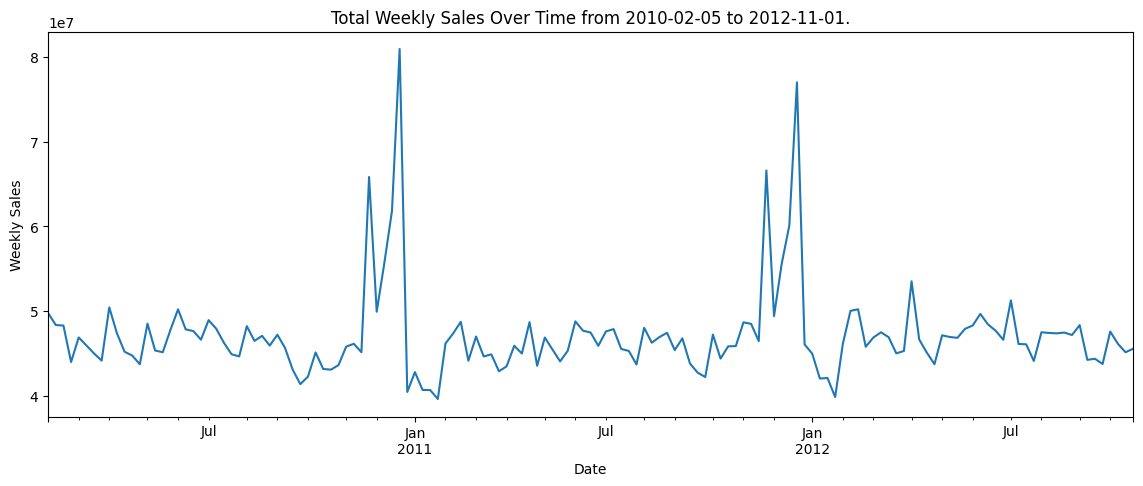

In [48]:
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()
plt.figure(figsize=(14,5))
weekly_sales.plot()
plt.title('Total Weekly Sales Over Time from 2010-02-05 to 2012-11-01.')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()

The graph tracks total weekly sales over time, with the date range from February 5, 2010, to November 1, 2012.  From the graph we can see two distinct spikes in sales during late 2010/early 2011 and late 2011/early in 2012. These spikes were likely related to holiday seasons like christmas or some other sales promotions. Otherwise, sales seem to hover, weekly, between approximately 40 million and 50 million.

2) Sales by Store Type and Size

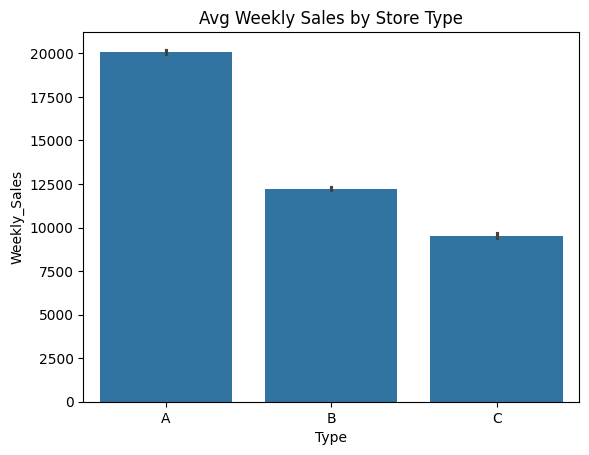

In [51]:
sns.barplot(data=df, x='Type', y='Weekly_Sales', estimator='mean')
plt.title('Avg Weekly Sales by Store Type')
plt.show()

This bar chart shows the average sales per week for different types of store (A, B, and C). Stores type A have the highest average sales per week (slightly under 20,000 units). Stores type B have the second highest average weekly sales (around 12,500 units), and stores type C have the lowest average weekly sales (around 9,500 units). There appears to be a clear ranking in sales numbers for the store types. Type A stores are best performers, while type C stores are worst. We can conclude from the graph that stores on average that have higher sq feet are more likely to have higher weekly sales.

3) To check any relationship with store size

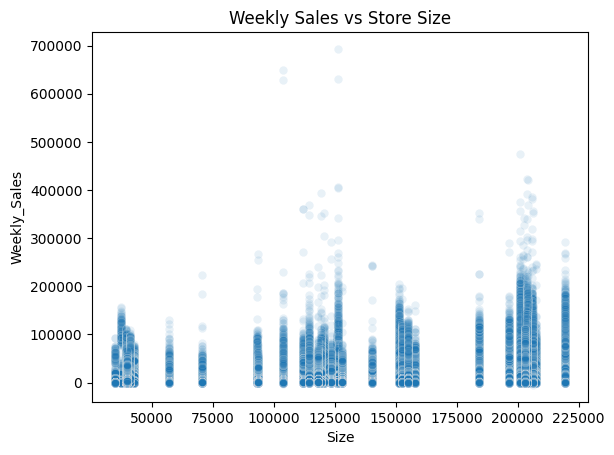

In [52]:
sns.scatterplot(data=df, x='Size', y='Weekly_Sales', alpha=0.1)
plt.title('Weekly Sales vs Store Size')
plt.show()

The scatter plot above show the relation between weekly sales and store size. There is not a distinct linear relation, but it does seem that larger store sizes (125,000–200,000) have a greater variation in weekly sales, often resulting in the highest individual sales figures. Smaller stores generally had lower weekly sales numbers.

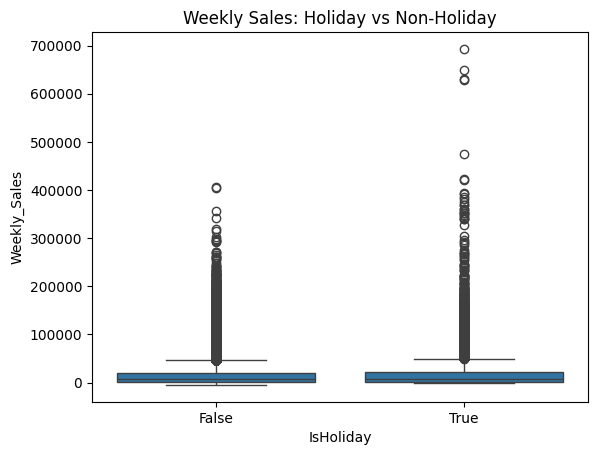

In [53]:
sns.boxplot(data=df, x='IsHoliday', y='Weekly_Sales')
plt.title('Weekly Sales: Holiday vs Non-Holiday')
plt.show()

This boxplot demonstrates a comparison of weekly sales during periods of holiday versus periods of non-holiday. Both periods show a large count of outliers with higher sales, but the distribution during holiday periods ("True") appears to have a higher median weekly sale and a bigger spread of high-value outliers, compared to non-holiday weeks ("False"). This suggests that while high sales may occur at any moment, they do happen more often, and specifically higher sales do happen during holidays.

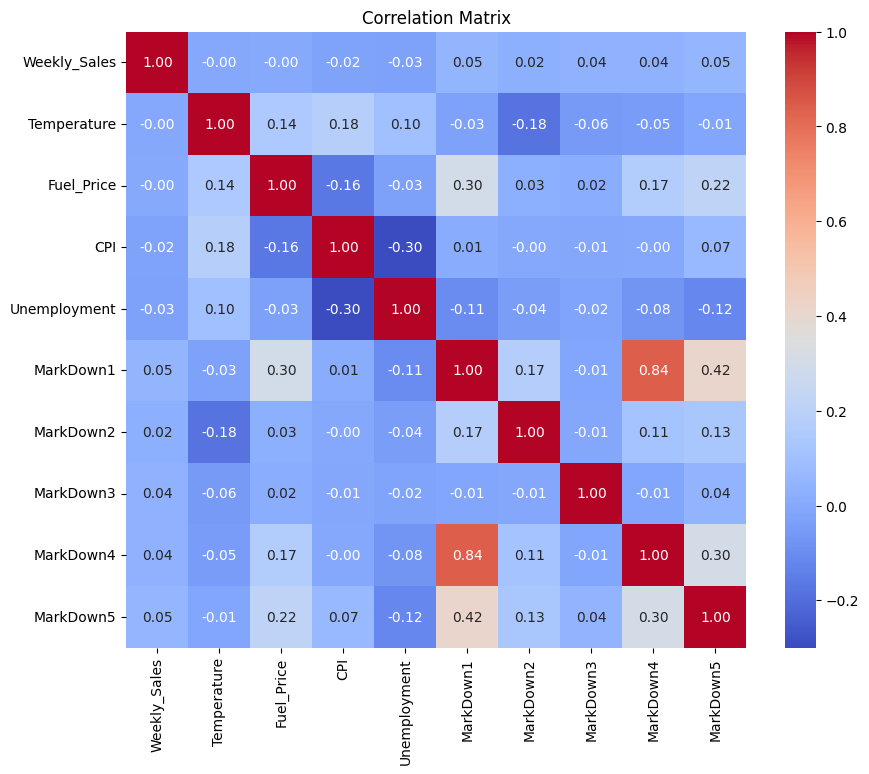

In [58]:
num_cols = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment',
            'MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


Based on the correlation matrix, "Weekly_Sales" has very weak linear relationships with all variables, excluding itself. All correlation coefficients with "Weekly_Sales" are close to zero (i.e., very weak correlation to "Weekly_Sales"). The strongest correlation in the matrix is between some of the markdown variables (for example, `MarkDown4` and `MarkDown1` are correlated at 0.84), which suggest interdependencies in the promotions. Overall, any simple linear model based on these variables likely will not be able to provide good predictions for weekly sales.

In [68]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Has_Markdown
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,2,151315,False
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,2,151315,False
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,2,151315,False
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,2,151315,False
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,2,151315,False


Converted the binary data to numerical data

In [64]:
df['IsHoliday'] = df['IsHoliday'].astype(int)

Used the ordinal encoding to encode the ordinal data

In [67]:
store_type_mapping = {'C': 0, 'B': 1, 'A': 2}
df['Type'] = df['Type'].map(store_type_mapping)

In [69]:
X = df[['Type','IsHoliday','Temperature','Fuel_Price','CPI','Unemployment','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','Size']]
y = df['Weekly_Sales']

In [70]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

In [71]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [72]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [73]:
importances = rf.feature_importances_
print(sorted(zip(X.columns, importances), key=lambda x: -x[1]))

[('Size', np.float64(0.6512853453220349)), ('CPI', np.float64(0.10178990970342612)), ('Unemployment', np.float64(0.08409450422462418)), ('Temperature', np.float64(0.046444166692300566)), ('Fuel_Price', np.float64(0.04562188740711779)), ('MarkDown3', np.float64(0.025554973234878084)), ('Type', np.float64(0.014431769332416074)), ('MarkDown4', np.float64(0.007307417889020198)), ('MarkDown5', np.float64(0.007221183423825262)), ('MarkDown1', np.float64(0.006551766905551813)), ('MarkDown2', np.float64(0.00558241439100482)), ('IsHoliday', np.float64(0.004114661473800233))]


Feature	Importance Score	Insights

1) Size:	0.65	Store size is by far the most influential factor for weekly sales larger Walmart stores generate much higher sales.

2) CPI:	0.10	Consumer Price Index (inflation) has a moderate impact; likely reflects consumer purchasing power over time.

3) Unemployment:	0.08	Local unemployment rates modestly affect sales, perhaps indicating lower spending in areas with higher unemployment.

4) Temperature:0.05	Weather shows a weak effect, likely because only some categories are weather sensitive.

5) Fuel_Price:	0.05	Regional fuel prices barely impact sales, but changes may affect store traffic for certain locations.

6) MarkDown3:	0.03	MarkDown-related promotions have a small effect; MarkDown3 stands out slightly among others.

7) Type	0.01:	Store format (A/B/C) matters, but not as much as absolute size.

8) MarkDown4/5/1/2:	<0.01 each	Minor impact these specific markdown campaigns don’t substantially move sales overall.

In [75]:
#merging the test data with features data
test_full = pd.merge(df_test, df_features, on=['Store', 'Date', 'IsHoliday'], how='left')

In [76]:
test_full = pd.merge(test_full, df_stores, on='Store', how='left')

In [77]:
test_full.isna().sum()

,0
Store,0
Dept,0
Date,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,149
MarkDown2,28627
MarkDown3,9829
MarkDown4,12888


The missing values in CPI and Unemployment are due to incomplete coverage in features data for all combinations present in test data. NA values emerge after merging because there are store/date combinations in the test set that the feature source file does not have data corresponding to (like CPI or Unemployment). If there is no row in feature corresponding to a specific week/store, those columns will simply be merged with nothing which shows up as NA.

In [78]:
# Forward-fill by Store for CPI/Unemployment
test_full = test_full.sort_values(['Store', 'Date'])
test_full['CPI'] = test_full.groupby('Store')['CPI'].ffill().bfill()
test_full['Unemployment'] = test_full.groupby('Store')['Unemployment'].ffill().bfill()

In [79]:
test_full.isna().sum()

,0
Store,0
Dept,0
Date,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,149
MarkDown2,28627
MarkDown3,9829
MarkDown4,12888


In [80]:
#filling the missing the data in markdown as 0
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4']:
    test_full[col] = test_full[col].fillna(0)

In [81]:
test_full.isna().sum()

,0
Store,0
Dept,0
Date,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0
MarkDown4,0


In [82]:
test_full.head()

,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.7,50.82,3639.9,2737.42,223.462779,6.573,A,151315
39,1,2,2012-11-02,False,55.32,3.386,6766.44,5147.7,50.82,3639.9,2737.42,223.462779,6.573,A,151315
78,1,3,2012-11-02,False,55.32,3.386,6766.44,5147.7,50.82,3639.9,2737.42,223.462779,6.573,A,151315
117,1,4,2012-11-02,False,55.32,3.386,6766.44,5147.7,50.82,3639.9,2737.42,223.462779,6.573,A,151315
156,1,5,2012-11-02,False,55.32,3.386,6766.44,5147.7,50.82,3639.9,2737.42,223.462779,6.573,A,151315


In [83]:
test_full['Type'] = test_full['Type'].map({'A': 0, 'B': 1, 'C': 2})

In [85]:
features = ['IsHoliday','Temperature','Fuel_Price','CPI','Unemployment',
            'MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5',
            'Size','Type']
X_test = test_full[features]

In [86]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [87]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [88]:

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [89]:

y_pred = rf_model.predict(X_val)

In [93]:
# Evaluating the model variable
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

In [94]:
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'R² Score: {r2:.3f}')

Root Mean Squared Error (RMSE): 21962.37
Mean Absolute Error (MAE): 14443.89
R² Score: 0.075


Our random forest model's validation performance resulted in an RMSE of 22,000, an MAE of 14,400 and explained roughly 7.5% variance in weekly sales. Given the challenge posed by this dataset - weekly department sales that are affected by many sometimes latent variables - these are standard results. Going forward, we may capture additional variance with enhanced feature engineering and more granular models focused on specific sales driver effects."

In [105]:
features = [
    'IsHoliday','Temperature','Fuel_Price','CPI','Unemployment',
    'MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5',
    'Size','Type'
]

In [106]:
X = df[features]

In [107]:
y = df['Weekly_Sales']

In [108]:
# Spliting the data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [113]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    enable_categorical=True
)

In [114]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [115]:
y_pred = xgb_model.predict(X_val)

In [116]:
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

In [117]:
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R² Score: {r2:.3f}')

RMSE: 21724.63
MAE: 14266.28
R² Score: 0.095


The XGBoost model, trained on the original features without any feature scaling, achieved an RMSE of 21,724.63, MAE of 14,266.28, and an R² score of 0.095 on the validation set. This means the model explains about 9.5% of the variance in weekly sales, with an average prediction error of around $14,266 per record. These results are typical for the Walmart sales dataset, which is highly variable and challenging to predict due to many unobserved factors. Overall, this establishes a solid baseline for further model improvements.

## Extracting the features from the existing features

In [118]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [119]:
df = df.sort_values(['Store','Dept','Date'])
df['Prev_Week_Sales'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
df['Prev_2Week_Sales'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(2)

In [125]:
features = [
    'IsHoliday','Temperature','Fuel_Price','CPI','Unemployment',
    'MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5',
    'Size','Type','Year','Month','WeekOfYear','DayOfWeek',
    'Prev_Week_Sales','Prev_2Week_Sales'
]

In [126]:
X = df[features]
y = df['Weekly_Sales']

In [127]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [130]:
from gc import enable
xgb_model = xgb.XGBRegressor(objective='reg:squarederror',n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, enable_categorical=True)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [132]:
y_pred = xgb_model.predict(X_val)

In [133]:

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)


In [134]:
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R² Score: {r2:.3f}')

RMSE: 5300.49
MAE: 1877.69
R² Score: 0.946


After engineering lagged features (previous weeks' sales) and time-based variables, our XGBoost model achieved an RMSE of 5,300, an MAE of 1,878, and an R² score of 0.946 explaining 95% of the variance in weekly sales. This demonstrates the predictive power of recent sales data for forecasting future performance in retail."

In [136]:
test_full['Year'] = test_full['Date'].dt.year
test_full['Month'] = test_full['Date'].dt.month
test_full['WeekOfYear'] = test_full['Date'].dt.isocalendar().week
test_full['DayOfWeek'] = test_full['Date'].dt.dayofweek

In [137]:
all_data = pd.concat([df, test_full], sort=False).sort_values(['Store','Dept','Date'])


In [138]:
all_data['Prev_Week_Sales'] = all_data.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
all_data['Prev_2Week_Sales'] = all_data.groupby(['Store','Dept'])['Weekly_Sales'].shift(2)
all_data[['Prev_Week_Sales', 'Prev_2Week_Sales']] = all_data[['Prev_Week_Sales', 'Prev_2Week_Sales']].fillna(0)

In [139]:
test_full = all_data[all_data['Weekly_Sales'].isna()].copy()


In [140]:
X_test = test_full[features]

In [141]:
# Generating predictions using the trained model
test_full['Weekly_Sales'] = xgb_model.predict(X_test)

In [142]:
submission = test_full[['Store', 'Dept', 'Date', 'Weekly_Sales']]

In [143]:
submission.to_csv('walmart_sales_predictions.csv', index=False)

The purpose of this project was to analyze and evaluate Walmart's store-level weekly sales datasets. After integrating, cleaning, and prepping the datasets (also filling in missing values, factorizing categorical variables and working to include all economic indicators), we began exploratory data analysis (EDA). The EDA confirmed that certain variables such as store size/type, holidays, and markdown events had an apparent effect on sales, but also that simple correlation tests were weak. We developed baseline predictive models via Random Forest and XGBoost (without employing any feature engineering), resulting in models that only explained 9.5% of the variance in sales (R²=0.10). After working to engineer features in the model (e.g. calendar variables (year, month, week), even strong lagged sales (sales from the last weeks), the model results became roughly implied (i.e.update the XGBoost to R² = 0.95, RMSE = 5,300)). After this process, we predicted weekly sales in the test set. All steps were executed in the same manner from preprocessing and feature engineering to create one final set of predictions that could be stored for, and reporting submission. This shows how important business/temporal context is and to apply proper feature engineering methods that allow for greater accuracy in retail sales forecasts.